<a href="https://colab.research.google.com/github/mus03/G3-Architects/blob/main/iris_recall_precision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question 4: Explore the concept of confusion matrix (precision, recall, trade-off) and the ROC
curve using Irish flower dataset**

In [ ]:
# import all the required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [ ]:
# Load the Dataset
# Read the Iris dataset from the CSV file into a dataframe
df = pd.read_csv('IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Separate Features and Target
# Split the data into X (flower features) and y (species labels)
X = df.iloc[:, :-1]
y = df["species"]

# Train–Test Split
# Divide the dataset into training and testing set

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, stratify=y, random_state=42)

# Train the Model
# Fit a Logistic Regression model so it learns the relationship between features and species.
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)


LogisticRegression(max_iter=500, random_state=42)

In [ ]:
# Use predict_proba() to get the probability of each class for every test sample
y_pred =  model.predict(X_test)

# Predict Class Probabilities (y_score)
y_score = model.predict_proba(X_test)
class_ids = model.classes_

In [ ]:
print("Test acc :", accuracy_score(y_test, y_pred))

Test acc : 0.9333333333333333


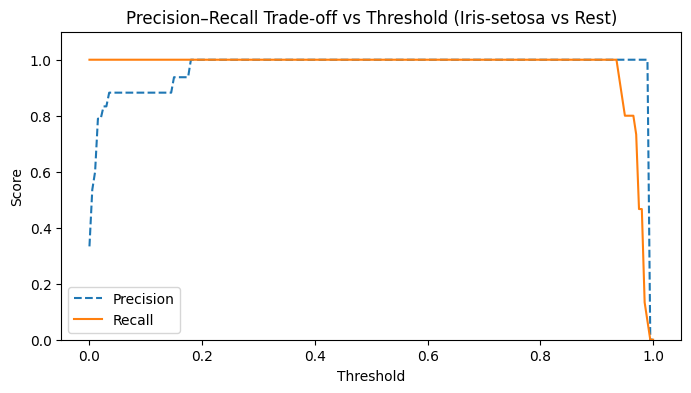

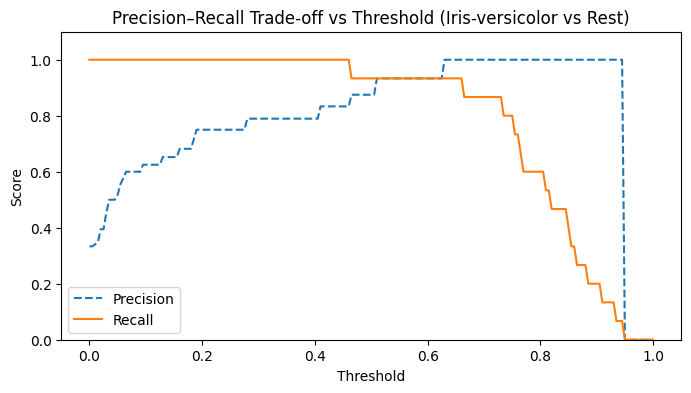

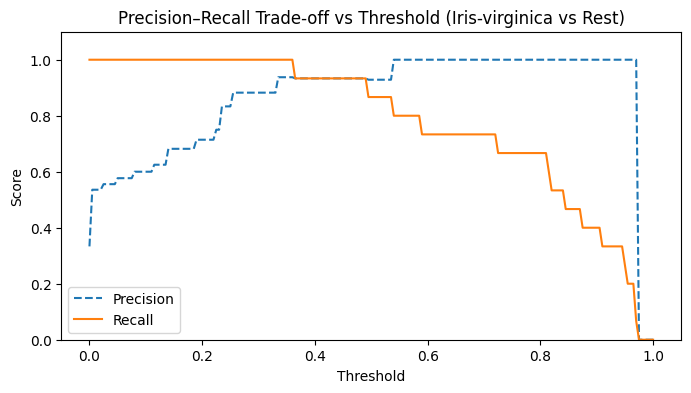

In [ ]:
thresholds = np.linspace(0, 1, 201)

for target_class in class_ids:
    i = list(class_ids).index(target_class)
   # Select One Class for One-vs-Rest (OvR) eg. setosa vs others
   # Analyze one species at a time by treating it as the positive class and the others as negative.
   # Convert the true labels into binary form: 1 for the selected class and 0 for the rest.
    y_true_bin = (y_test == target_class).astype(int)

    # Take the probability column corresponding to the selected class from y_score
    y_proba = y_score[:, i]

    # analyze PR for each threshold
    precisions, recalls = [], []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true_bin, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_true_bin, y_pred_t))

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, precisions, linestyle="--", label="Precision")
    plt.plot(thresholds, recalls, label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1.10)
    plt.title(f"Precision–Recall Trade-off vs Threshold ({target_class} vs Rest)")
    plt.legend()
    plt.show()


confusion matrix:a table used to evaluate a classification model by comparing the actual class labels with the predicted class labels, showing how many predictions are correct or incorrect
Precision measures how many predicted positives are correct.
Recall measures how many actual positives were correctly predicted.

In [ ]:
# Apply the Threshold to Make Predictions
# Convert probabilities into binary predictions using probability ≥ threshold then the predicted value is 1

for target_class in class_ids:
    i = list(class_ids).index(target_class)

    # One vs Rest binary labels and probability for this class
    y_true_bin = (y_test == target_class).astype(int)
    y_proba = y_score[:, i]

    chosen_threshold = 0.55
    y_pred_bin = (y_proba >= chosen_threshold).astype(int)

#Calculate Precision and Recall
# Measure how accurate the positive predictions are (precision)
# how many true positives were detected (recall).

    p = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    r = recall_score(y_true_bin, y_pred_bin)

    print(f"\nClass: {target_class} (vs Rest)")
    print(f"Chosen threshold: {chosen_threshold}")
    print(f"Precision: {p:.4f}")
    print(f"Recall   : {r:.4f}")


Class: Iris-setosa (vs Rest)
Chosen threshold: 0.55
Precision: 1.0000
Recall   : 1.0000

Class: Iris-versicolor (vs Rest)
Chosen threshold: 0.55
Precision: 0.9333
Recall   : 0.9333

Class: Iris-virginica (vs Rest)
Chosen threshold: 0.55
Precision: 1.0000
Recall   : 0.8000


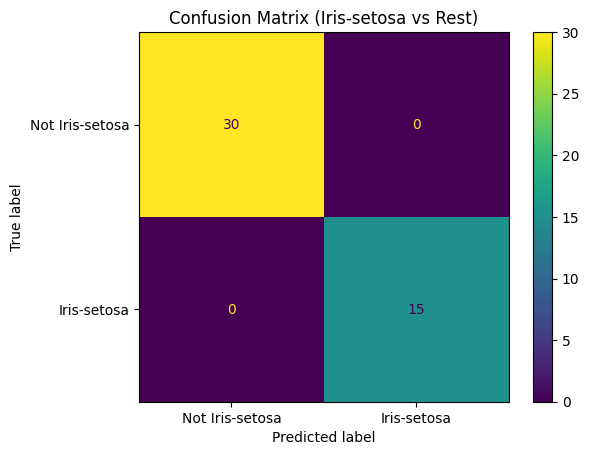

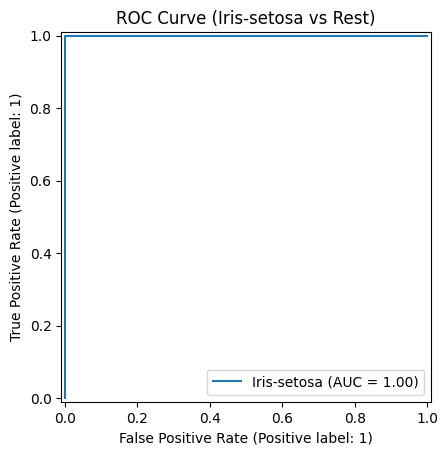

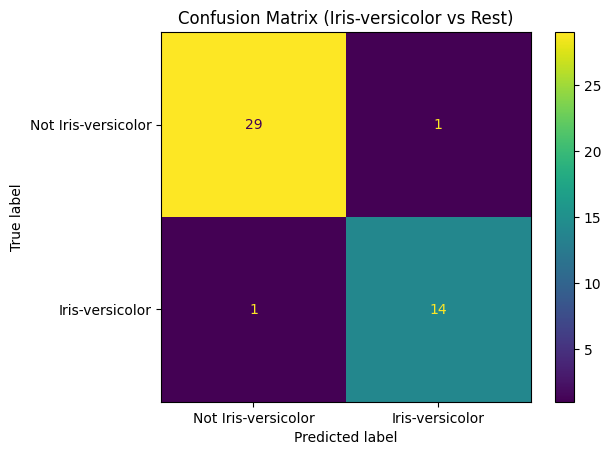

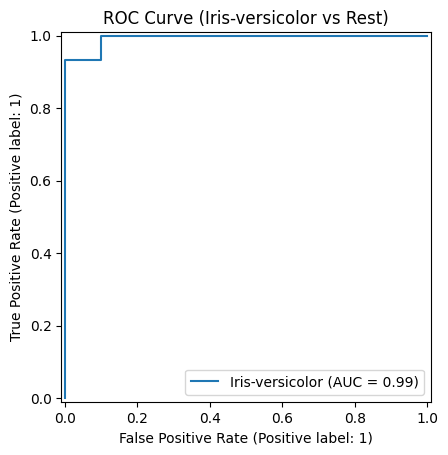

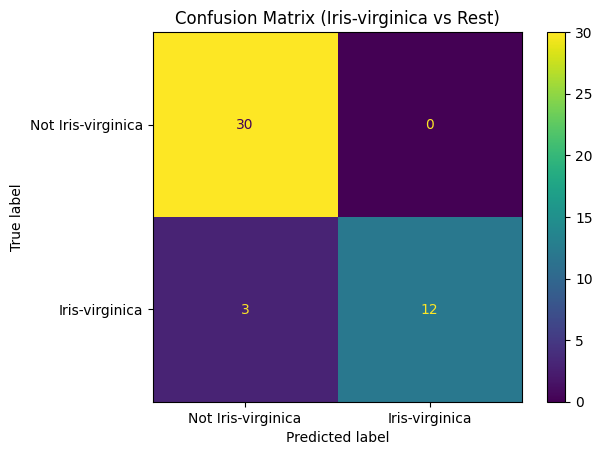

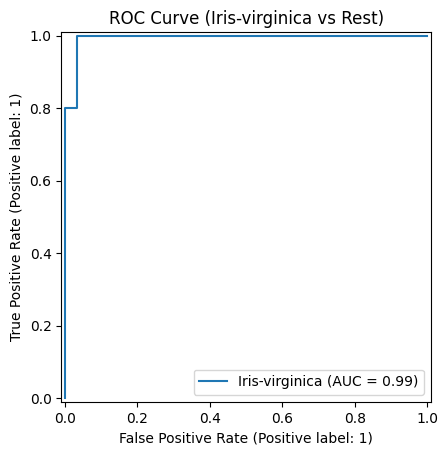

In [ ]:
for target_class in class_ids:
    i = list(class_ids).index(target_class)

    # OvR binary labels and probability for this class
    y_true_bin = (y_test == target_class).astype(int)
    y_proba = y_score[:, i]

    chosen_threshold = 0.55
    y_pred_bin = (y_proba >= chosen_threshold).astype(int)

    # Confusion matrix> display the counts of True Positives, False Positives, False Negatives, and True Negatives.
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f"Not {target_class}", target_class])
    disp.plot()
    plt.title(f"Confusion Matrix ({target_class} vs Rest)")
    plt.show()

    # ROC curve> Show the relationship between True Positive Rate and False Positive Rate across all thresholds.
    # ROC curve is used to evaluate how well a model can separate different classes.
    #TPR (True Positive Rate / Recall): TP / (TP + FN)
    #The proportion of actual positive cases that the model correctly identifies.
    # FPR (False Positive Rate): FP / (FP + TN)
    # The proportion of actual negative cases that the model incorrectly predicts as positive
    RocCurveDisplay.from_predictions(y_true_bin, y_proba, name=target_class)
    plt.title(f"ROC Curve ({target_class} vs Rest)")
    plt.show()
